In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sqlite3

# Connect to database
conn = sqlite3.connect('data/finflow.db')

In [3]:
# Test - load customers table
df_customers = pd.read_sql_query("SELECT * FROM customers", conn)
df_customers.head()

,customer_id,company_name,industry,country,signup_date,sales_rep
0,1,Wilson-Randall,Retail,USA,2023-10-17,Priya M.
1,2,Campbell-Thompson,Healthcare,UK,2022-09-08,Sarah K.
2,3,Mcguire Group,Manufacturing,Germany,2023-11-24,Sarah K.
3,4,Knight-Wiggins,Finance,USA,2023-08-28,Sarah K.
4,5,"Tucker, Lane and Guzman",Healthcare,UK,2022-04-06,Linda W.


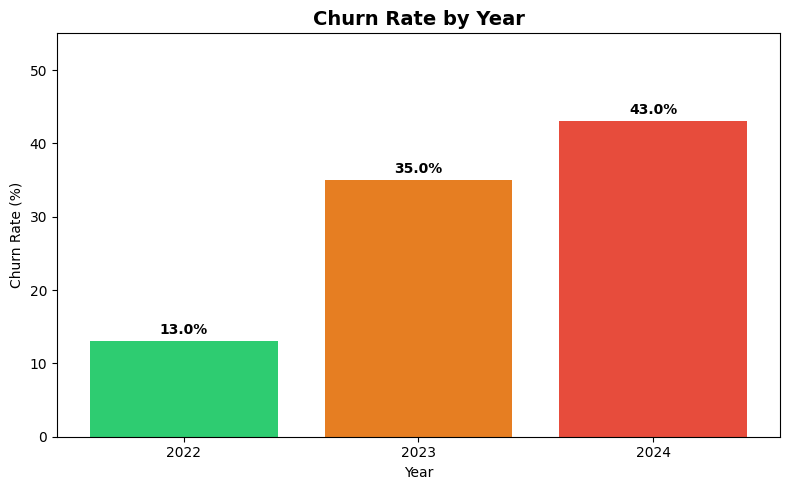

In [6]:
query = """
SELECT 
    strftime('%Y', cancellation_date) AS year,
    COUNT(*) AS churned
FROM cancellations
GROUP BY year
ORDER BY year
"""

df_churned = pd.read_sql_query(query, conn)

# Manual churn rate using our verified numbers
df_churn = pd.DataFrame({
    'year': ['2022', '2023', '2024'],
    'churn_rate': [13.0, 35.0, 43.0]
})

plt.figure(figsize=(8, 5))
plt.bar(df_churn['year'], df_churn['churn_rate'], color=['#2ecc71', '#e67e22', '#e74c3c'])
plt.title('Churn Rate by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)
for i, v in enumerate(df_churn['churn_rate']):
    plt.text(i, v + 1, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/01_churn_rate_by_year.png', dpi=150)
plt.show()

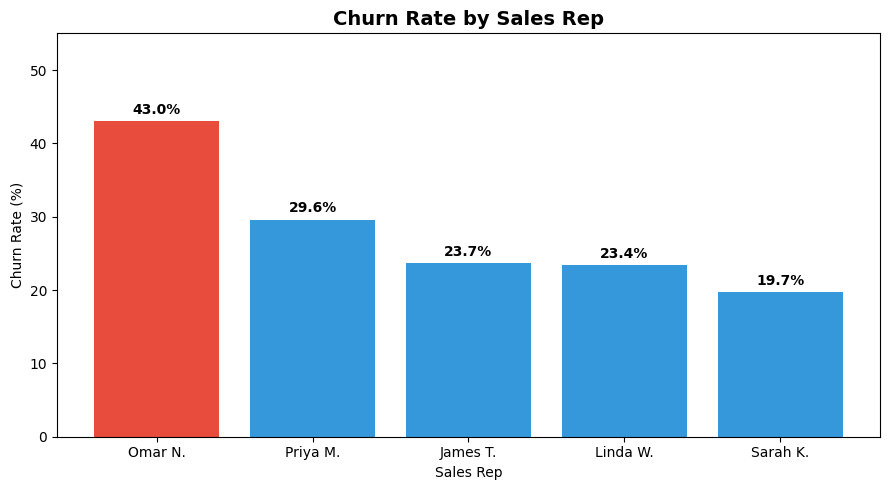

In [7]:
# Visualization 2: Churn Rate by Sales Rep
query = """
SELECT 
    c.sales_rep,
    COUNT(DISTINCT s.customer_id) AS total_customers,
    COUNT(DISTINCT cn.customer_id) AS churned_customers,
    ROUND(COUNT(DISTINCT cn.customer_id) * 100.0 / COUNT(DISTINCT s.customer_id), 1) AS churn_rate_pct
FROM customers c
JOIN subscriptions s ON s.customer_id = c.customer_id
LEFT JOIN cancellations cn ON cn.customer_id = c.customer_id
GROUP BY c.sales_rep
ORDER BY churn_rate_pct DESC
"""

df_reps = pd.read_sql_query(query, conn)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if rep == 'Omar N.' else '#3498db' for rep in df_reps['sales_rep']]
plt.bar(df_reps['sales_rep'], df_reps['churn_rate_pct'], color=colors)
plt.title('Churn Rate by Sales Rep', fontsize=14, fontweight='bold')
plt.xlabel('Sales Rep')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)
for i, v in enumerate(df_reps['churn_rate_pct']):
    plt.text(i, v + 1, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_churn_by_sales_rep.png', dpi=150)
plt.show()

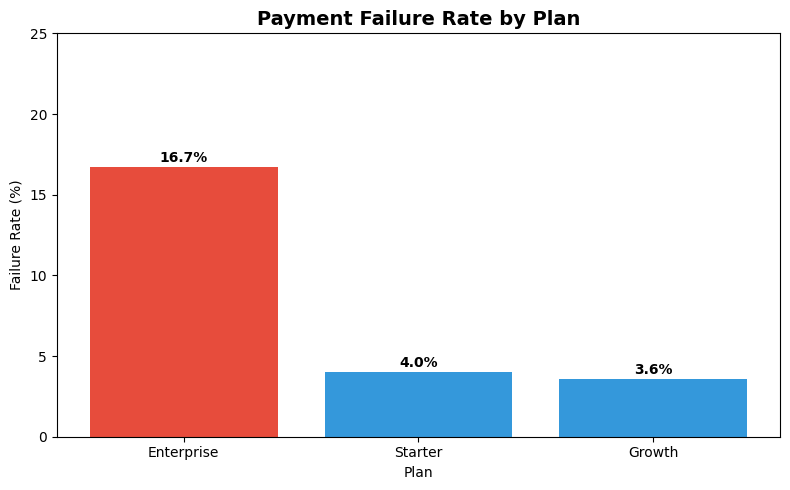

In [8]:
# Visualization 3: Payment Failure Rate by Plan
query = """
SELECT 
    s.plan,
    COUNT(*) AS total_payments,
    SUM(CASE WHEN p.status = 'failed' THEN 1 ELSE 0 END) AS failed_payments,
    ROUND(SUM(CASE WHEN p.status = 'failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS failure_rate_pct
FROM payments p
JOIN subscriptions s ON s.subscription_id = p.subscription_id
GROUP BY s.plan
ORDER BY failure_rate_pct DESC
"""

df_payments = pd.read_sql_query(query, conn)

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if plan == 'Enterprise' else '#3498db' for plan in df_payments['plan']]
plt.bar(df_payments['plan'], df_payments['failure_rate_pct'], color=colors)
plt.title('Payment Failure Rate by Plan', fontsize=14, fontweight='bold')
plt.xlabel('Plan')
plt.ylabel('Failure Rate (%)')
plt.ylim(0, 25)
for i, v in enumerate(df_payments['failure_rate_pct']):
    plt.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_payment_failure_by_plan.png', dpi=150)
plt.show()

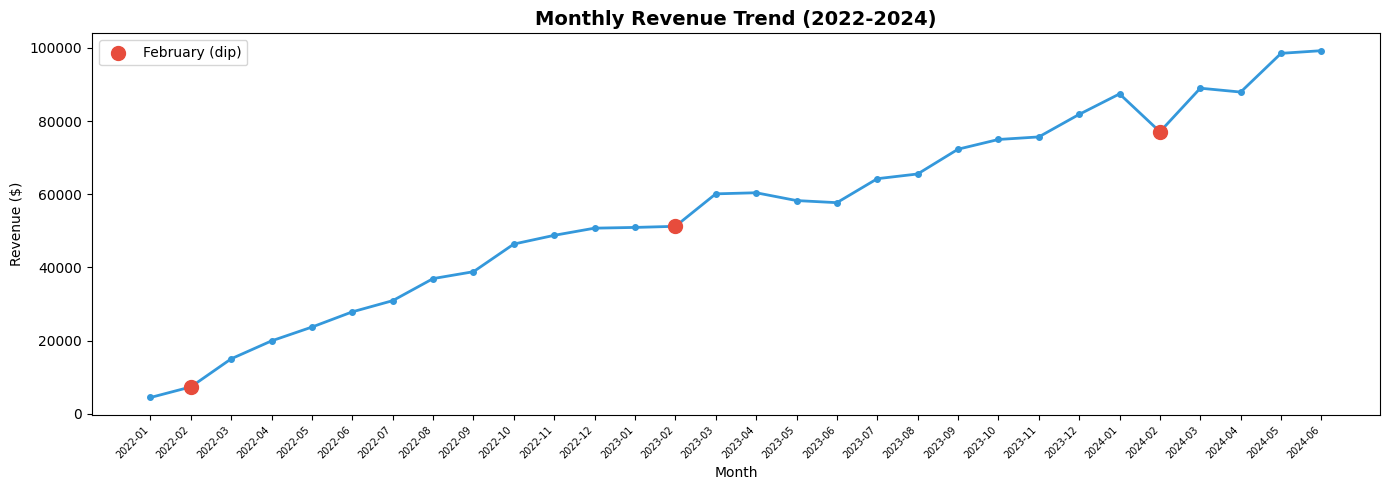

In [9]:
# Visualization 4: Monthly Revenue Trend
query = """
SELECT 
    strftime('%Y-%m', payment_date) AS month,
    SUM(amount) AS total_revenue
FROM payments
WHERE status = 'success'
GROUP BY month
ORDER BY month
"""

df_revenue = pd.read_sql_query(query, conn)

plt.figure(figsize=(14, 5))
plt.plot(df_revenue['month'], df_revenue['total_revenue'], 
         color='#3498db', linewidth=2, marker='o', markersize=4)

# Highlight February dips
feb_months = df_revenue[df_revenue['month'].str.endswith('-02')]
plt.scatter(feb_months['month'], feb_months['total_revenue'], 
            color='#e74c3c', zorder=5, s=100, label='February (dip)')

plt.title('Monthly Revenue Trend (2022-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.legend()
plt.tight_layout()
plt.savefig('charts/04_monthly_revenue_trend.png', dpi=150)
plt.show()